#  MobileNetV2 — Warping Defect Detection

This notebook trains a **MobileNetV2** transfer-learning model to classify surface images as **Warping** or **No Warping**.

| Step | Description |
|------|-------------|
| 1 | Load & preprocess data |
| 2 | Build the model |
| 3 | Compile |
| 4 | Train |
| 5 | Evaluate |
| 6 | Save |

---
##  Imports & Configuration

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPUs available: {tf.config.list_physical_devices('GPU')}")

2026-05-10 22:44:32.293966: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778449472.321272  163660 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778449472.329237  163660 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-10 22:44:32.376877: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.18.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Step 1 — Load and Preprocess Data

* Point to `data/` folder (contains `Warping/` and `No_Warping/` sub-folders)
* Resize all images to **224 × 224**
* Normalize pixels to **[0, 1]**
* Split: **80 % train / 10 % validation / 10 % test**
* Apply **augmentation on training set only** (rotation, flip, brightness)
* Batch size = **32**

In [2]:
# ---------- paths ----------
DATA_DIR = os.path.join(os.getcwd(), "..", "data")

# ---------- constants ----------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ---------- collect all file paths + labels ----------
import glob, random

Warping_files   = sorted(glob.glob(os.path.join(DATA_DIR, "Warping", "*.jpg")))
no_Warping_files = sorted(glob.glob(os.path.join(DATA_DIR, "No_Warping", "*.jpg")))

print(f"Warping images    : {len(Warping_files)}")
print(f"No_Warpingmages : {len(no_Warping_files)}")

# Label: Warping = 1, No_Warping = 0
all_files  = Warping_files + no_Warping_files
all_labels = [1] * len(Warping_files) + [0] * len(no_Warping_files)

# Shuffle together
combined = list(zip(all_files, all_labels))
random.seed(SEED)
random.shuffle(combined)
all_files, all_labels = zip(*combined)
all_files  = list(all_files)
all_labels = list(all_labels)

total = len(all_files)
train_end = int(0.8 * total)
val_end   = int(0.9 * total)

train_files, train_labels = all_files[:train_end],       all_labels[:train_end]
val_files,   val_labels   = all_files[train_end:val_end], all_labels[train_end:val_end]
test_files,  test_labels  = all_files[val_end:],          all_labels[val_end:]

print(f"\nTrain : {len(train_files)}")
print(f"Val   : {len(val_files)}")
print(f"Test  : {len(test_files)}")

Warping images    : 1707
No_Warpingmages : 1815

Train : 2817
Val   : 352
Test  : 353


### 1.1 — Build `tf.data` pipelines with augmentation

In [3]:
def load_and_preprocess(file_path, label):
    """Read an image file, decode, resize, and normalise to [0,1]."""
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label


def augment(img, label):
    """Apply data-augmentation (training set only)."""
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    # Random rotation (up to 20 degrees ≈ 0.35 rad)
    # tf.image doesn't have random_rotation, so we use keras layer below
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


# --- Augmentation layer for rotation ---
rotation_layer = layers.RandomRotation(factor=0.06, seed=SEED)  # ~20°

def augment_with_rotation(img, label):
    img = rotation_layer(img, training=True)
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


# --- Datasets ---
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_files, train_labels))
    .shuffle(len(train_files), seed=SEED)
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .map(augment_with_rotation, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_files, val_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((test_files, test_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("✅ Data pipelines ready.")

I0000 00:00:1778449482.501314  163660 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5815 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


✅ Data pipelines ready.


### 1.2 — Visualise a batch of training images

2026-04-24 18:38:04.485750: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 36990720 exceeds 10% of free system memory.
2026-04-24 18:38:04.485921: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 36990720 exceeds 10% of free system memory.
2026-04-24 18:38:04.485970: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 36990720 exceeds 10% of free system memory.
2026-04-24 18:38:04.486618: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 36990720 exceeds 10% of free system memory.
2026-04-24 18:38:04.486747: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 36990720 exceeds 10% of free system memory.
2026-04-24 18:38:05.345561: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to b

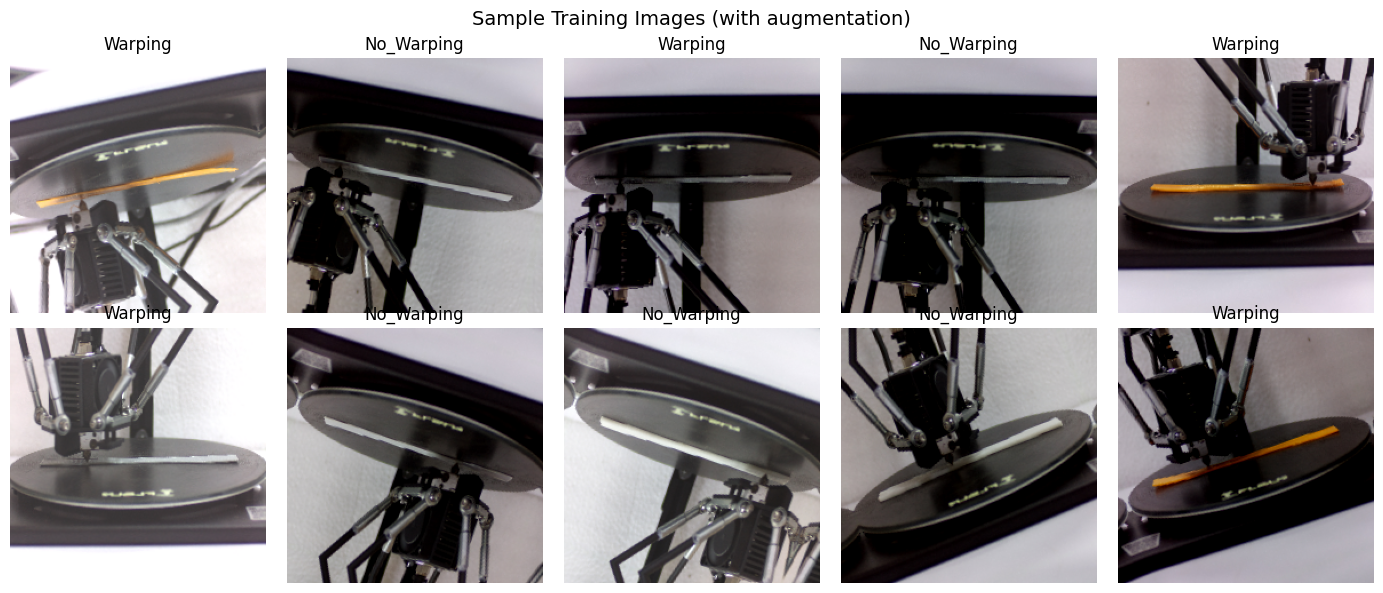

In [7]:
class_names = ["No_Warping", "Warping"]

plt.figure(figsize=(14, 6))
for images, labels in train_ds.take(1):
    for i in range(min(10, len(images))):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.suptitle("Sample Training Images (with augmentation)", fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 2 — Build the Model

* Load **MobileNetV2** pretrained on ImageNet (`include_top=False`)
* **Freeze** all base layers
* Add: `GlobalAveragePooling2D → Dense(256, relu) → Dropout(0.3) → Dense(1, sigmoid)`

In [8]:
# ---------- Load pretrained base ----------
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
)

# Freeze all base layers
base_model.trainable = False

print(f"Base model layers : {len(base_model.layers)}")
print(f"Trainable weights : {len(base_model.trainable_weights)}")

# ---------- Build classification head ----------
inputs = keras.Input(shape=(224, 224, 3), name="input_image")
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.Dropout(0.3, name="dropout_03")(x)
outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

model = keras.Model(inputs, outputs, name="MobileNetV2_Warping")
model.summary()

Base model layers : 154
Trainable weights : 0


Model: "MobileNetV2_Warping"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_03 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

---
## Step 3 — Compile

* Optimizer: **Adam** (lr = 0.0001)
* Loss: **binary_crossentropy**
* Metrics: **accuracy**

In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

print("✅ Model compiled.")

✅ Model compiled.


---
## Step 4 — Train

* Epochs: **50**
* Callbacks:
  * `EarlyStopping` — patience = 10, monitor `val_loss`
  * `ReduceLROnPlateau` — factor 0.5, patience 5
  * `ModelCheckpoint` — save best model

In [10]:
EPOCHS = 50
BEST_MODEL_PATH = "best_mobilenetv2_Warping.h5"

cb_list = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cb_list,
)

print("\n✅ Training complete.")

Epoch 1/50


I0000 00:00:1777052292.887083  441546 service.cc:148] XLA service 0x7232a8010250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777052292.887262  441546 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2060 SUPER, Compute Capability 7.5
2026-04-24 18:38:13.277796: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777052294.498669  441546 cuda_dnn.cc:529] Loaded cuDNN version 90300


 3/89 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.4375 - loss: 0.8223  

I0000 00:00:1777052298.895998  441546 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 631ms/step - accuracy: 0.5243 - loss: 0.7463
Epoch 1: val_loss improved from None to 0.52932, saving model to best_mobilenetv2_Warping.h5


...


Epoch 38: finished saving model to best_mobilenetv2_Warping.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 58s 645ms/step - accuracy: 0.8736 - loss: 0.3036 - val_accuracy: 0.8864 - val_loss: 0.2461 - learning_rate: 1.0000e-04
Epoch 39/50
86/89 ━━━━━━━━━━━━━━━━━━━━ 1s 643ms/step - accuracy: 0.8541 - loss: 0.3259
Epoch 39: val_loss improved from 0.24608 to 0.24071, saving model to best_mobilenetv2_Warping.h5



Epoch 39: finished saving model to best_mobilenetv2_Warping.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 50s 557ms/step - accuracy: 0.8591 - loss: 0.3246 - val_accuracy: 0.9062 - val_loss: 0.2407 - learning_rate: 1.0000e-04
Epoch 40/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - accuracy: 0.8727 - loss: 0.3092
Epoch 40: val_loss did not improve from 0.24071
89/89 ━━━━━━━━━━━━━━━━━━━━ 49s 544ms/step - accuracy: 0.8669 - loss: 0.3112 - val_accuracy: 0.9034 - val_loss: 0.2410 - learning_rate: 1.0000e-04
Epoch 41/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - accuracy: 0.8771 - loss: 0.3025
Epoch 41: val_loss did not improve from 0.24071
89/89 ━━━━━━━━━━━━━━━━━━━━ 63s 700ms/step - accuracy: 0.8789 - loss: 0.3051 - val_accuracy: 0.8807 - val_loss: 0.2436 - learning_rate: 1.0000e-04
Epoch 42/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.8742 - loss: 0.3004
Epoch 42: val_loss improved from 0.24071 to 0.23563, saving model to best_mobilenetv2_Warping.h5



Epoch 42: finished saving model to best_mobilenetv2_Warping.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 50s 555ms/step - accuracy: 0.8782 - loss: 0.2943 - val_accuracy: 0.9091 - val_loss: 0.2356 - learning_rate: 1.0000e-04
Epoch 43/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.8726 - loss: 0.3028
Epoch 43: val_loss did not improve from 0.23563
89/89 ━━━━━━━━━━━━━━━━━━━━ 48s 535ms/step - accuracy: 0.8758 - loss: 0.3000 - val_accuracy: 0.8920 - val_loss: 0.2403 - learning_rate: 1.0000e-04
Epoch 44/50
81/89 ━━━━━━━━━━━━━━━━━━━━ 7s 919ms/step - accuracy: 0.8755 - loss: 0.3017 
Epoch 44: val_loss improved from 0.23563 to 0.23547, saving model to best_mobilenetv2_Warping.h5



Epoch 44: finished saving model to best_mobilenetv2_Warping.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 59s 801ms/step - accuracy: 0.8662 - loss: 0.3137 - val_accuracy: 0.9091 - val_loss: 0.2355 - learning_rate: 1.0000e-04
Epoch 45/50
81/89 ━━━━━━━━━━━━━━━━━━━━ 5s 664ms/step - accuracy: 0.8710 - loss: 0.3093
Epoch 45: val_loss did not improve from 0.23547
89/89 ━━━━━━━━━━━━━━━━━━━━ 50s 560ms/step - accuracy: 0.8729 - loss: 0.3046 - val_accuracy: 0.8750 - val_loss: 0.2619 - learning_rate: 1.0000e-04
Epoch 46/50
82/89 ━━━━━━━━━━━━━━━━━━━━ 4s 704ms/step - accuracy: 0.8795 - loss: 0.3030 
Epoch 46: val_loss did not improve from 0.23547
89/89 ━━━━━━━━━━━━━━━━━━━━ 53s 598ms/step - accuracy: 0.8761 - loss: 0.2974 - val_accuracy: 0.8949 - val_loss: 0.2852 - learning_rate: 1.0000e-04
Epoch 47/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.8777 - loss: 0.2908
Epoch 47: val_loss did not improve from 0.23547
89/89 ━━━━━━━━━━━━━━━━━━━━ 61s 683ms/step - accuracy: 0.8786 - loss: 0.2876 - val_accuracy: 


Epoch 49: finished saving model to best_mobilenetv2_Warping.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 51s 567ms/step - accuracy: 0.8765 - loss: 0.2918 - val_accuracy: 0.9119 - val_loss: 0.2277 - learning_rate: 1.0000e-04
Epoch 50/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.8801 - loss: 0.2771
Epoch 50: val_loss did not improve from 0.22770
89/89 ━━━━━━━━━━━━━━━━━━━━ 49s 547ms/step - accuracy: 0.8779 - loss: 0.2875 - val_accuracy: 0.8892 - val_loss: 0.2594 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 49.

✅ Training complete.


---
## Step 5 — Evaluate

* Load best saved model
* Run on test set
* Print: **accuracy, precision, recall, F1-score**
* Plot: **confusion matrix, ROC curve, training/validation accuracy & loss curves**

### 5.1 — Load best model & predict on test set

In [ ]:
# Load best checkpoint
best_model = keras.models.load_model(BEST_MODEL_PATH)

# Predict
y_pred_probs = best_model.predict(test_ds).ravel()
y_pred = (y_pred_probs >= 0.5).astype(int)
y_true = np.array(test_labels)

print(f"Test samples : {len(y_true)}")

NameError: name 'best_model' is not defined

### 5.2 — Classification metrics

In [12]:
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)

print("="*50)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("="*50)
print()
print(classification_report(y_true, y_pred, target_names=class_names))

  Accuracy  : 0.9065
  Precision : 0.9017
  Recall    : 0.9070
  F1-Score  : 0.9043

              precision    recall  f1-score   support

  No_Warping       0.91      0.91      0.91       181
     Warping       0.90      0.91      0.90       172

    accuracy                           0.91       353
   macro avg       0.91      0.91      0.91       353
weighted avg       0.91      0.91      0.91       353



### 5.3 — Confusion Matrix

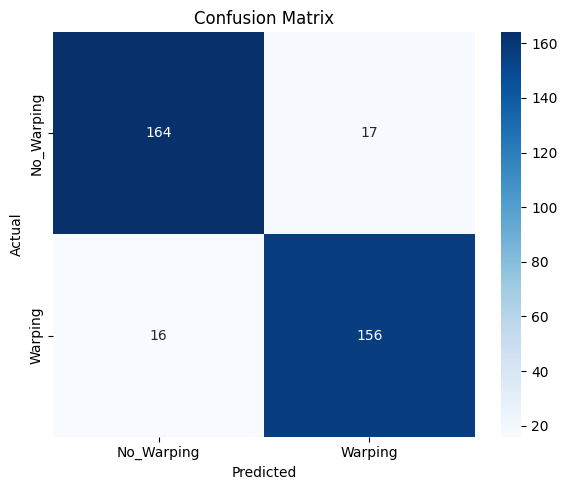

In [13]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

### 5.4 — ROC Curve

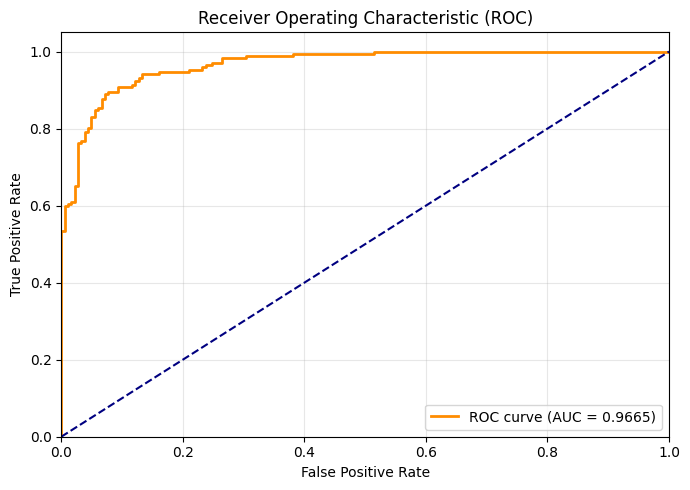

In [14]:
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5 — Training / Validation Accuracy & Loss Curves

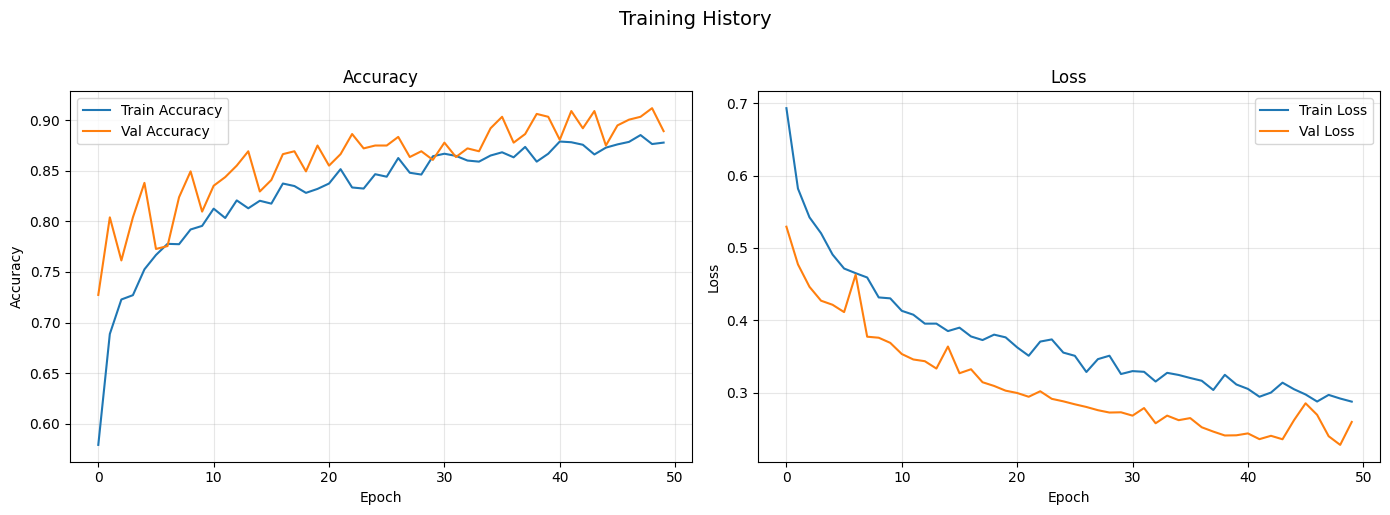

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history["accuracy"],    label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history["loss"],     label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Training History", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Step 6 — Save the Model

* Save as **`.h5`** (Keras format)
* Save as **`SavedModel`** format (for later TFLite conversion)

In [16]:
# 1) Save as .h5
H5_PATH = "mobilenetv2_Warping_final.h5"
best_model.save(H5_PATH)
print(f"✅ Model saved as HDF5       → {H5_PATH}")

# 2) Save as SavedModel directory
SAVED_MODEL_DIR = "mobilenetv2_Warping_savedmodel"
best_model.save(SAVED_MODEL_DIR)
print(f"✅ Model saved as SavedModel → {SAVED_MODEL_DIR}/")

✅ Model saved as HDF5       → mobilenetv2_Warping_final.h5


ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=mobilenetv2_Warping_savedmodel.

---
## Round 1 — Fine-Tuning: Unfreeze Last 20 Layers

The base model was fully frozen during the first training phase (only the custom head was trained).  
Here we apply **fine-tuning** by selectively unfreezing the **last 20 layers** of MobileNetV2 and training with a very low learning rate.

| Hyperparameter | Phase 1 (original) | Phase 2 (fine-tuning) |
|----------------|--------------------|-----------------------|
| Base model layers | **All frozen** (0 trainable) | **Last 20 unfrozen** |
| Learning rate | 0.0001 (1e-4) | **0.00001 (1e-5)** |
| Loss | binary_crossentropy | binary_crossentropy |
| Batch size | 32 | 32 |
| Max epochs | 50 | 50 |
| Callbacks | EarlyStopping / ReduceLR / Checkpoint | same |
| Data | same train/val/test splits | same |

> **Why 1e-5?** Fine-tuning requires a much smaller LR than initial training (10× lower here)  
> to avoid destroying the pre-learned ImageNet features in the unfrozen layers.

### Step 1 — Load the best model from Phase 1

In [4]:
# Load the best checkpoint saved during Phase 1
ft_model = keras.models.load_model("best_mobilenetv2_Warping.h5")
print("✅ Phase-1 best model loaded.")

✅ Phase-1 best model loaded.


### Step 2 — Unfreeze the last 20 layers of the MobileNetV2 base

We target only the top of the base model (high-level, task-specific features).  
The early layers (low-level edge/texture detectors) stay frozen to preserve ImageNet weights.

In [5]:
# Locate the MobileNetV2 base inside the loaded model
base_model = ft_model.get_layer("mobilenetv2_1.00_224")

# Keep all base layers frozen first, then selectively unfreeze the last 20
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Summary of trainable status
total   = len(base_model.layers)
frozen  = sum(not l.trainable for l in base_model.layers)
unfrozen = sum(l.trainable for l in base_model.layers)
print(f"Base model total layers : {total}")
print(f"  Frozen                : {frozen}")
print(f"  Unfrozen (last 20)    : {unfrozen}")
print()
ft_model.summary()

Base model total layers : 154
  Frozen                : 134
  Unfrozen (last 20)    : 20



Model: "MobileNetV2_Warping"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_03 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,179 (9.87 MB)

 Trainable params: 1,534,273 (5.85 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

 Optimizer params: 2 (12.00 B)

### Step 3 — Recompile with a 10× lower learning rate

A very low LR (`1e-5`) lets the unfrozen weights adapt gently to the warping task  
without catastrophically forgetting the ImageNet features.

In [6]:
FT_LR = 1e-5   # 10× lower than original 1e-4

ft_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=FT_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

print(f"✅ Model recompiled — learning rate = {FT_LR}")

✅ Model recompiled — learning rate = 1e-05


### Step 4 — Callbacks (same as Phase 1) & Train

The best fine-tuned model is saved to a **new file** so Phase 1 weights are not overwritten.

In [7]:
FT_EPOCHS = 50
FT_BEST_MODEL_PATH = "best_mobilenetv2_Warping_finetuned.h5"

ft_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=FT_BEST_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
]

# Fine-tune on the same train_ds / val_ds used in Phase 1
ft_history = ft_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FT_EPOCHS,
    callbacks=ft_callbacks,
)

print("\n✅ Fine-tuning complete.")

Epoch 1/50


I0000 00:00:1778449531.568014  163940 service.cc:148] XLA service 0x77c88c00eb00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778449531.568846  163940 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2060 SUPER, Compute Capability 7.5
2026-05-10 22:45:31.975013: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778449534.090840  163940 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/89 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.7734 - loss: 0.5628  

I0000 00:00:1778449542.479775  163940 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.7660 - loss: 0.5156
Epoch 1: val_loss improved from None to 0.29247, saving model to best_mobilenetv2_Warping_finetuned.h5


...


Epoch 29: finished saving model to best_mobilenetv2_Warping_finetuned.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 49s 549ms/step - accuracy: 0.9258 - loss: 0.1875 - val_accuracy: 0.9375 - val_loss: 0.1545 - learning_rate: 5.0000e-06
Epoch 30/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.9295 - loss: 0.1808
Epoch 30: val_loss did not improve from 0.15453
89/89 ━━━━━━━━━━━━━━━━━━━━ 43s 474ms/step - accuracy: 0.9318 - loss: 0.1797 - val_accuracy: 0.8977 - val_loss: 0.2293 - learning_rate: 5.0000e-06
Epoch 31/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.9297 - loss: 0.1842
Epoch 31: val_loss did not improve from 0.15453
89/89 ━━━━━━━━━━━━━━━━━━━━ 42s 471ms/step - accuracy: 0.9315 - loss: 0.1788 - val_accuracy: 0.9318 - val_loss: 0.1685 - learning_rate: 5.0000e-06
Epoch 32/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.9260 - loss: 0.1983
Epoch 32: val_loss did not improve from 0.15453
89/89 ━━━━━━━━━━━━━━━━━━━━ 42s 475ms/step - accuracy: 0.9251 - loss: 0.1903 - val_a


Epoch 35: finished saving model to best_mobilenetv2_Warping_finetuned.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 43s 477ms/step - accuracy: 0.9237 - loss: 0.1913 - val_accuracy: 0.9375 - val_loss: 0.1527 - learning_rate: 2.5000e-06
Epoch 36/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9263 - loss: 0.1825
Epoch 36: val_loss did not improve from 0.15271
89/89 ━━━━━━━━━━━━━━━━━━━━ 42s 474ms/step - accuracy: 0.9315 - loss: 0.1737 - val_accuracy: 0.9375 - val_loss: 0.1718 - learning_rate: 2.5000e-06
Epoch 37/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.9290 - loss: 0.1826
Epoch 37: val_loss did not improve from 0.15271
89/89 ━━━━━━━━━━━━━━━━━━━━ 42s 469ms/step - accuracy: 0.9286 - loss: 0.1752 - val_accuracy: 0.9261 - val_loss: 0.1882 - learning_rate: 2.5000e-06
Epoch 38/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.9452 - loss: 0.1438
Epoch 38: val_loss did not improve from 0.15271
89/89 ━━━━━━━━━━━━━━━━━━━━ 50s 559ms/step - accuracy: 0.9357 - loss: 0.1587 - val_a


Epoch 40: finished saving model to best_mobilenetv2_Warping_finetuned.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 42s 471ms/step - accuracy: 0.9379 - loss: 0.1688 - val_accuracy: 0.9489 - val_loss: 0.1341 - learning_rate: 2.5000e-06
Epoch 41/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.9289 - loss: 0.1728
Epoch 41: val_loss did not improve from 0.13415
89/89 ━━━━━━━━━━━━━━━━━━━━ 42s 474ms/step - accuracy: 0.9279 - loss: 0.1751 - val_accuracy: 0.9403 - val_loss: 0.1545 - learning_rate: 2.5000e-06
Epoch 42/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.9377 - loss: 0.1593
Epoch 42: val_loss did not improve from 0.13415
89/89 ━━━━━━━━━━━━━━━━━━━━ 36s 401ms/step - accuracy: 0.9329 - loss: 0.1672 - val_accuracy: 0.9432 - val_loss: 0.1483 - learning_rate: 2.5000e-06
Epoch 43/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.9401 - loss: 0.1573
Epoch 43: val_loss improved from 0.13415 to 0.13352, saving model to best_mobilenetv2_Warping_finetuned.h5



Epoch 43: finished saving model to best_mobilenetv2_Warping_finetuned.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 43s 484ms/step - accuracy: 0.9354 - loss: 0.1625 - val_accuracy: 0.9517 - val_loss: 0.1335 - learning_rate: 2.5000e-06
Epoch 44/50
85/89 ━━━━━━━━━━━━━━━━━━━━ 1s 494ms/step - accuracy: 0.9313 - loss: 0.1689
Epoch 44: val_loss did not improve from 0.13352
89/89 ━━━━━━━━━━━━━━━━━━━━ 43s 474ms/step - accuracy: 0.9340 - loss: 0.1647 - val_accuracy: 0.9318 - val_loss: 0.1678 - learning_rate: 2.5000e-06
Epoch 45/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.9331 - loss: 0.1727
Epoch 45: val_loss did not improve from 0.13352
89/89 ━━━━━━━━━━━━━━━━━━━━ 43s 476ms/step - accuracy: 0.9343 - loss: 0.1705 - val_accuracy: 0.9403 - val_loss: 0.1427 - learning_rate: 2.5000e-06
Epoch 46/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.9396 - loss: 0.1613
Epoch 46: val_loss improved from 0.13352 to 0.12117, saving model to best_mobilenetv2_Warping_finetuned.h5



Epoch 46: finished saving model to best_mobilenetv2_Warping_finetuned.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 42s 472ms/step - accuracy: 0.9322 - loss: 0.1731 - val_accuracy: 0.9545 - val_loss: 0.1212 - learning_rate: 2.5000e-06
Epoch 47/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.9381 - loss: 0.1592
Epoch 47: val_loss did not improve from 0.12117
89/89 ━━━━━━━━━━━━━━━━━━━━ 49s 542ms/step - accuracy: 0.9407 - loss: 0.1553 - val_accuracy: 0.9545 - val_loss: 0.1253 - learning_rate: 2.5000e-06
Epoch 48/50
86/89 ━━━━━━━━━━━━━━━━━━━━ 1s 424ms/step - accuracy: 0.9372 - loss: 0.1622
Epoch 48: val_loss did not improve from 0.12117
89/89 ━━━━━━━━━━━━━━━━━━━━ 36s 402ms/step - accuracy: 0.9407 - loss: 0.1581 - val_accuracy: 0.9432 - val_loss: 0.1380 - learning_rate: 2.5000e-06
Epoch 49/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.9448 - loss: 0.1528
Epoch 49: val_loss did not improve from 0.12117
89/89 ━━━━━━━━━━━━━━━━━━━━ 48s 538ms/step - accuracy: 0.9397 - loss: 0.1617 - val_a

### Step 5 — Evaluate the fine-tuned model on the test set

In [13]:
ft_best = keras.models.load_model(FT_BEST_MODEL_PATH)

ft_y_pred_probs = ft_best.predict(test_ds, verbose=1).ravel()
ft_y_pred       = (ft_y_pred_probs >= 0.5).astype(int)
y_true = np.concatenate([y for _, y in test_ds], axis=0)

ft_acc  = accuracy_score(y_true, ft_y_pred)
ft_prec = precision_score(y_true, ft_y_pred)
ft_rec  = recall_score(y_true, ft_y_pred)
ft_f1   = f1_score(y_true, ft_y_pred)

print("=" * 50)
print(f"  Accuracy  : {ft_acc:.4f}  ({ft_acc*100:.2f}%)")
print(f"  Precision : {ft_prec:.4f}")
print(f"  Recall    : {ft_rec:.4f}")
print(f"  F1-Score  : {ft_f1:.4f}")
print("=" * 50)
print()
print(classification_report(
    y_true, ft_y_pred,
    target_names=["No_Warping", "Warping"]
))

12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 452ms/step
  Accuracy  : 0.9377  (93.77%)
  Precision : 0.8989
  Recall    : 0.9826
  F1-Score  : 0.9389

              precision    recall  f1-score   support

  No_Warping       0.98      0.90      0.94       181
     Warping       0.90      0.98      0.94       172

    accuracy                           0.94       353
   macro avg       0.94      0.94      0.94       353
weighted avg       0.94      0.94      0.94       353



2026-05-10 23:35:22.181738: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Step 6 — Training History: Phase 1 vs Fine-Tuning

Plot both training runs side-by-side to see whether fine-tuning improved generalization.

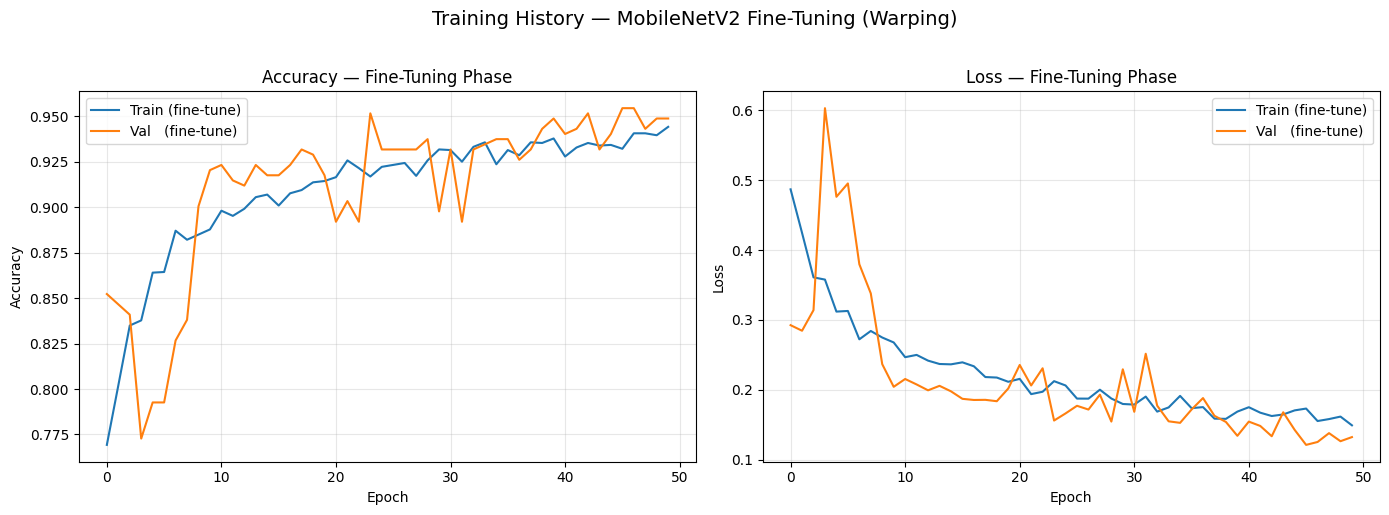

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy ──
axes[0].plot(ft_history.history["accuracy"],     label="Train (fine-tune)")
axes[0].plot(ft_history.history["val_accuracy"],  label="Val   (fine-tune)")
axes[0].set_title("Accuracy — Fine-Tuning Phase")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Loss ──
axes[1].plot(ft_history.history["loss"],     label="Train (fine-tune)")
axes[1].plot(ft_history.history["val_loss"],  label="Val   (fine-tune)")
axes[1].set_title("Loss — Fine-Tuning Phase")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Training History — MobileNetV2 Fine-Tuning (Warping)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Step 7 — Save the Fine-Tuned Model

In [15]:
FT_FINAL_PATH = "mobilenetv2_Warping_finetuned_final.h5"
ft_best.save(FT_FINAL_PATH)
print(f"✅ Fine-tuned model saved → {FT_FINAL_PATH}")

✅ Fine-tuned model saved → mobilenetv2_Warping_finetuned_final.h5


---
### ✅ Done!

The trained MobileNetV2 model for **Warping vs No_Warping** detection is now saved and ready for deployment or TFLite conversion.